In [ ]:
# Jalankan ini di cell pertama untuk install YOLOv8
!pip install ultralytics

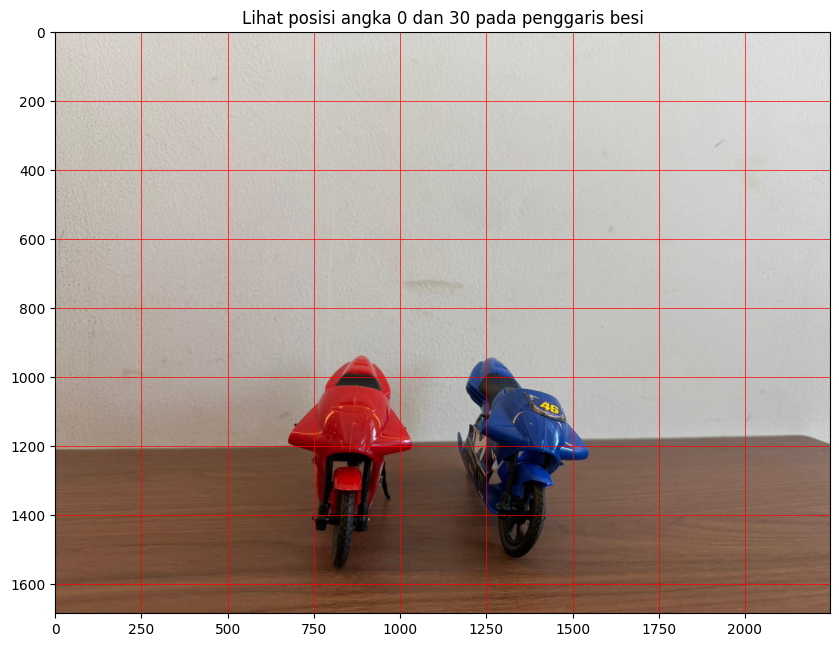

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Baca foto simulasi 1
img = cv2.imread('/content/drive/MyDrive/train_slotparkir/3.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Tampilkan foto dengan sumbu koordinat (grid)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.grid(True, color='red', linestyle='-', linewidth=0.5)
plt.title("Lihat posisi angka 0 dan 30 pada penggaris besi")
plt.show()

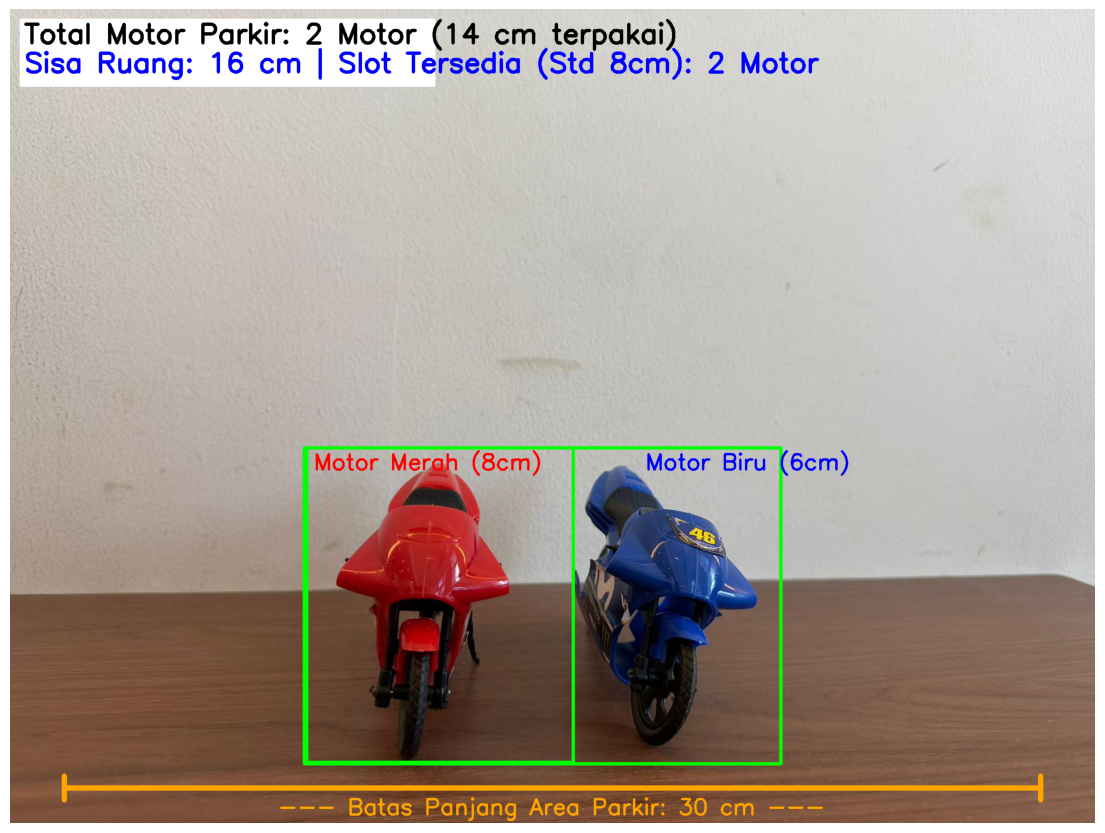

In [ ]:
# 1. PASANG LIBRARY ROBOFLOW (Wajib dijalankan agar tidak error)
!pip install roboflow

import cv2
import os
import matplotlib.pyplot as plt
from roboflow import Roboflow

# ==========================================================
# KONFIGURASI PROTOTIPE BARU (UKURAN BERBEDA)
# ==========================================================
PANJANG_PARKIR_CM = 30
UKURAN_MERAH_CM = 8       # Motor Merah = 8 cm
UKURAN_BIRU_CM = 6        # Motor Biru = 6 cm

image_path = '/content/drive/MyDrive/train_slotparkir/3.jpeg'

# --- VALIDASI GAMBAR ---
if not os.path.exists(image_path):
    print(f"❌ ERROR: File '{image_path}' tidak ditemukan di folder Google Colab!")
else:
    frame = cv2.imread(image_path)
    if frame is None:
        print("❌ ERROR: Gambar rusak atau tidak didukung!")
    else:
        H, W, _ = frame.shape

        # PANGGIL MODEL LEWAT CLOUD API ROBOFLOW
        API_KEY_KAMU = "KLKWxyxBwKf1AtEebWKe"
        rf = Roboflow(api_key=API_KEY_KAMU)
        project = rf.project("object-detect-felan")
        model = project.version(2).model

        prediction = model.predict(image_path, confidence=30).json()

        jumlah_motor_terdeteksi = 0
        total_body_motor_cm = 0  # Akumulator ruang terpakai dinamis
        Y_TERBAWAH = 0

        # Ambil data hasil deteksi dari respons JSON API
        for predictions in prediction['predictions']:
            label = predictions['class']
            jumlah_motor_terdeteksi += 1

            # Koordinat bounding box
            x = predictions['x']
            y = predictions['y']
            width = predictions['width']
            height = predictions['height']

            x_min = int(x - (width / 2))
            y_min = int(y - (height / 2))
            x_max = int(x + (width / 2))
            y_max = int(y + (height / 2))

            if y_max > Y_TERBAWAH:
                Y_TERBAWAH = y_max

            # GAMBAR KOTAK PEMBATAS HIJAU
            cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), (0, 255, 0), int(H/300))

            # LOGIKA PEMBEDA UKURAN DAN WARNA TEKS
            if 'merah' in label.lower():
                total_body_motor_cm += UKURAN_MERAH_CM # Tambah 8 cm
                posisi_x = x_min + 15
                warna_teks = (0, 0, 255)
                nama_tampilan = f"Motor Merah ({UKURAN_MERAH_CM}cm)"
            elif 'biru' in label.lower():
                total_body_motor_cm += UKURAN_BIRU_CM  # Tambah 6 cm
                posisi_x = x_max - 280 # Geser ke kanan dalam box
                warna_teks = (255, 0, 0)
                nama_tampilan = f"Motor Biru ({UKURAN_BIRU_CM}cm)"
            else:
                total_body_motor_cm += UKURAN_MERAH_CM # Default jika tidak terbaca
                posisi_x = x_min + 15
                warna_teks = (0, 255, 255)
                nama_tampilan = label

            posisi_y = y_min + 45
            cv2.putText(frame, f"{nama_tampilan}", (posisi_x, posisi_y),
                        cv2.FONT_HERSHEY_SIMPLEX, H/1100, warna_teks, int(H/350))

        # ==========================================================
        # LOGIKA MATEMATIKA BARU (DINAMIS BERDASARKAN WARNA)
        # ==========================================================
        sisa_ruang_cm = PANJANG_PARKIR_CM - total_body_motor_cm
        if sisa_ruang_cm < 0: sisa_ruang_cm = 0

        # Slot tersedia dihitung berdasarkan kapasitas motor merah (8cm) sebagai standar minimum baku
        slot_tersedia = int(sisa_ruang_cm // UKURAN_MERAH_CM)

        # ==========================================================
        # GAMBAR GARIS 30 CM SAMPAI UJUNG FRAME GAMBAR
        # ==========================================================
        y_garis = Y_TERBAWAH + 50 if Y_TERBAWAH > 0 else int(H * 0.85)
        x_start_papan = int(W * 0.05)
        x_end_papan = int(W * 0.95)

        # Garis horizontal utama & sirip siku vertikal pembatas
        cv2.line(frame, (x_start_papan, y_garis), (x_end_papan, y_garis), (0, 165, 255), int(H/180))
        cv2.line(frame, (x_start_papan, y_garis - 25), (x_start_papan, y_garis + 25), (0, 165, 255), int(H/180))
        cv2.line(frame, (x_end_papan, y_garis - 25), (x_end_papan, y_garis + 25), (0, 165, 255), int(H/180))

        teks_garis = f"--- Batas Panjang Area Parkir: {PANJANG_PARKIR_CM} cm ---"
        lebar_teks_garis = cv2.getTextSize(teks_garis, cv2.FONT_HERSHEY_SIMPLEX, H/1100, int(H/400))[0][0]
        x_teks_tengah = int((W / 2) - (lebar_teks_garis / 2))

        cv2.putText(frame, teks_garis, (x_teks_tengah, y_garis + 55),
                    cv2.FONT_HERSHEY_SIMPLEX, H/1100, (0, 165, 255), int(H/350))

        # ==========================================================
        # VISUALISASI PANEL INFORMASI DI ATAS GAMBAR
        # ==========================================================
        text_line1 = f"Total Motor Parkir: {jumlah_motor_terdeteksi} Motor ({total_body_motor_cm} cm terpakai)"
        text_line2 = f"Sisa Ruang: {sisa_ruang_cm} cm | Slot Tersedia (Std 8cm): {slot_tersedia} Motor"

        skala_teks = H / 900
        ketebalan_teks = int(H / 300)

        cv2.rectangle(frame, (20, 20), (880, 160), (255, 255, 255), -1)
        cv2.putText(frame, text_line1, (30, 70), cv2.FONT_HERSHEY_SIMPLEX, skala_teks, (0, 0, 0), ketebalan_teks)
        cv2.putText(frame, text_line2, (30, 130), cv2.FONT_HERSHEY_SIMPLEX, skala_teks, (255, 0, 0), ketebalan_teks)

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(14, 12))
        plt.imshow(frame_rgb)
        plt.axis('off')
        plt.show()